### Import Cleaned .csv

In [38]:
import pandas as pd

df = pd.read_csv("kalshi_data_clean.csv")
print("This dataset has", len(df), "observations.")
df.head()

This dataset has 205321 observations.


,title,last_price_dollars,result,date
0,Will the White House Press Secretary say Treas...,0.99,yes,2025-03-17
1,Will the White House Press Secretary say Infra...,0.01,no,2025-03-17
2,Will the White House Press Secretary say Immig...,0.99,yes,2025-03-17
3,Will the White House Press Secretary say Fort ...,0.01,no,2025-03-17
4,Will the White House Press Secretary say Elon ...,0.99,yes,2025-03-17


### Contract Binning

In [113]:
import numpy as np
import pandas as pd

# 1. Binning contracts by every ten cents
# 2. Cut attribute 'bin' for predicting contract probability

bin = np.arange(0, 1.01, 0.1)
df['bin'] = pd.cut(df['last_price_dollars'], bin)
df.head()

,title,last_price_dollars,result,date,bin,result_binary
0,Will the White House Press Secretary say Treas...,0.99,yes,2025-03-17,"(0.9, 1.0]",1.0
1,Will the White House Press Secretary say Infra...,0.01,no,2025-03-17,"(0.0, 0.1]",0.0
2,Will the White House Press Secretary say Immig...,0.99,yes,2025-03-17,"(0.9, 1.0]",1.0
3,Will the White House Press Secretary say Fort ...,0.01,no,2025-03-17,"(0.0, 0.1]",0.0
4,Will the White House Press Secretary say Elon ...,0.99,yes,2025-03-17,"(0.9, 1.0]",1.0


### Predicted Mean Logic 

In [114]:
# Group probabilities into bins to compare predicted mean frequency
pred_freq = (
    df.groupby("bin", observed=True)
      .agg(
          count=("last_price_dollars", "size"),
          pred_mean=("last_price_dollars", "mean"),
      )
      .reset_index()
)

pred_freq

,bin,count,pred_mean
0,"(0.0, 0.1]",116233,0.020925
1,"(0.1, 0.2]",10288,0.148137
2,"(0.2, 0.3]",4907,0.250489
3,"(0.3, 0.4]",3230,0.353628
4,"(0.4, 0.5]",2443,0.462063
5,"(0.5, 0.6]",2137,0.556289
6,"(0.6, 0.7]",2118,0.658305
7,"(0.7, 0.8]",2575,0.761208
8,"(0.8, 0.9]",4462,0.864516
9,"(0.9, 1.0]",56928,0.983083


### Observed Mean Logic

In [115]:
# Map "yes"/"no" outcomes to 1/0 binary for easier probability aggregation
df["result_binary"] = df["result"].map({"yes": 1, "no": 0})

df.head()

,title,last_price_dollars,result,date,bin,result_binary
0,Will the White House Press Secretary say Treas...,0.99,yes,2025-03-17,"(0.9, 1.0]",1.0
1,Will the White House Press Secretary say Infra...,0.01,no,2025-03-17,"(0.0, 0.1]",0.0
2,Will the White House Press Secretary say Immig...,0.99,yes,2025-03-17,"(0.9, 1.0]",1.0
3,Will the White House Press Secretary say Fort ...,0.01,no,2025-03-17,"(0.0, 0.1]",0.0
4,Will the White House Press Secretary say Elon ...,0.99,yes,2025-03-17,"(0.9, 1.0]",1.0


In [116]:
obs_freq = (
    df.groupby("bin", observed=True)
      .agg(
          obs_mean=("result_binary", "mean"),
      )
      .reset_index()
)

obs_freq

,bin,obs_mean
0,"(0.0, 0.1]",0.004432
1,"(0.1, 0.2]",0.052120
2,"(0.2, 0.3]",0.122503
3,"(0.3, 0.4]",0.220433
4,"(0.4, 0.5]",0.365125
5,"(0.5, 0.6]",0.515676
6,"(0.6, 0.7]",0.685080
7,"(0.7, 0.8]",0.820583
8,"(0.8, 0.9]",0.916629
9,"(0.9, 1.0]",0.989794


### Bootstrap

In [117]:
# 2. Bootstrap observed outcomes within each bin to estimate uncertainty

bootstrap_results = []

for b, subset in df.groupby("bin", observed=True):
    
    if len(subset) == 0:
        continue
    
    boot_means = []
    
    for _ in range(1000):
        sample = subset.sample(frac=1, replace=True)
        boot_means.append(sample["result_binary"].mean())
    
    ci_low = np.percentile(boot_means, 2.5)
    ci_high = np.percentile(boot_means, 97.5)
    
    bootstrap_results.append((b, ci_low, ci_high))

bootstrap_df = pd.DataFrame(
    bootstrap_results,
    columns=["bin", "ci_low", "ci_high"]
).sort_values(by="bin")

bootstrap_df

,bin,ci_low,ci_high
0,"(0.0, 0.1]",0.004053,0.004853
1,"(0.1, 0.2]",0.047841,0.056314
2,"(0.2, 0.3]",0.112945,0.131880
3,"(0.3, 0.4]",0.206502,0.234056
4,"(0.4, 0.5]",0.347114,0.384363
5,"(0.5, 0.6]",0.494151,0.536266
6,"(0.6, 0.7]",0.664778,0.704910
7,"(0.7, 0.8]",0.804660,0.834184
8,"(0.8, 0.9]",0.908337,0.924927
9,"(0.9, 1.0]",0.988968,0.990585


### Result Calibration Table

In [120]:
# Merge predicted, observed, and bootstrap data for final calibration analysis
result_df = pred_freq.merge(obs_freq, on="bin") \
                    .merge(bootstrap_df, on="bin")

result_df.to_csv("calibration_results.csv", index=False)
result_df

,bin,count,pred_mean,obs_mean,ci_low,ci_high
0,"(0.0, 0.1]",116233,0.020925,0.004432,0.004053,0.004853
1,"(0.1, 0.2]",10288,0.148137,0.052120,0.047841,0.056314
2,"(0.2, 0.3]",4907,0.250489,0.122503,0.112945,0.131880
3,"(0.3, 0.4]",3230,0.353628,0.220433,0.206502,0.234056
4,"(0.4, 0.5]",2443,0.462063,0.365125,0.347114,0.384363
5,"(0.5, 0.6]",2137,0.556289,0.515676,0.494151,0.536266
6,"(0.6, 0.7]",2118,0.658305,0.685080,0.664778,0.704910
7,"(0.7, 0.8]",2575,0.761208,0.820583,0.804660,0.834184
8,"(0.8, 0.9]",4462,0.864516,0.916629,0.908337,0.924927
9,"(0.9, 1.0]",56928,0.983083,0.989794,0.988968,0.990585


### Calibration Visualization

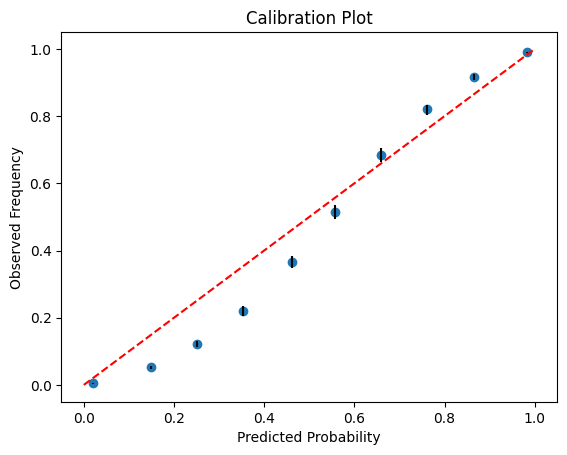

In [122]:
import matplotlib.pyplot as plt

# Plot predicted vs observed probabilities with bootstrap CI

plt.figure()

plt.scatter(result_df["pred_mean"], 
            result_df["obs_mean"],
            )

plt.errorbar(
    result_df["pred_mean"],
    result_df["obs_mean"],
    yerr=[
        result_df["obs_mean"] - result_df["ci_low"],
        result_df["ci_high"] - result_df["obs_mean"]
    ],
    fmt='none',
    color="black"
)

plt.plot([0, 1], 
         [0, 1], 
         linestyle='--',
         color="red"
         )

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Plot")

plt.savefig("calibration_plot.png", dpi=300, bbox_inches="tight")
plt.show()